<a href="https://colab.research.google.com/github/jolineuichanco/DataAnalytics/blob/main/Week08_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 8 demo**

Recall last week's MBA admission data where we used a logistic regression to predict admission decisions.

In [1]:
# first download the data
import pandas as pd

url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
df = pd.read_csv(url)

df.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


Let's split the data into a training set and testing set. The logistic model is trained from the training set only.

In [2]:
from sklearn.model_selection import train_test_split

# our features are "gre", "gpa", "rank"
X = df[['gre', 'gpa', 'rank']]
# our response variable is "admit"
y = df['admit']

# split the data into training and testing (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [3]:
# fit a logistic model using sklearn
from sklearn.linear_model import LogisticRegression

# our features are "gre", "gpa", "rank"
X = df[['gre', 'gpa', 'rank']]
# our response variable is "admit"
y = df['admit']

# create an instance of Logistic Regression
model = LogisticRegression()
model.fit(X, y)

print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


Let's evaluate how the model can predict admission decisions on the testing set. Last week, we used the default threshold of `0.5` to convert probabilities into binary predictions. That is, predict `admit` if `p > 0.5` and `not admit` if `p < 0.5`.

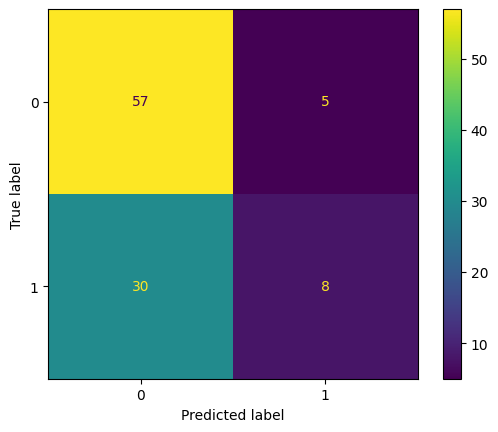

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions on the test set
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot()

In [5]:
TN, FP, FN, TP = cm.ravel()

# Calculate True Positive Rate (TPR) / Recall
tpr = TP / (TP + FN)

# Calculate False Positive Rate (FPR)
fpr = FP / (FP + TN)

print(f'True Positive Rate (TPR): {tpr:.4f}')
print(f'False Positive Rate (FPR): {fpr:.4f}')

True Positive Rate (TPR): 0.2105
False Positive Rate (FPR): 0.0806


## K-Fold Cross-Validation Demonstration

K-fold cross-validation is a technique to evaluate a model's performance by dividing the dataset into `k` subsets (folds). The model is then trained `k` times, each time holding out one fold for testing and training on the remaining `k-1` folds. The results are averaged to provide a more reliable performance estimate.

In [7]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Define the number of folds
k = 5

# Initialize the KFold splitter
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize the Logistic Regression model
model_kfold = LogisticRegression()

# Perform k-fold cross-validation
# The 'scoring' parameter defines the metric to evaluate, e.g., 'accuracy'
scores = cross_val_score(model_kfold, X_train, y_train, cv=kf, scoring='accuracy')

print(f'Accuracy scores for each of the {k} folds:')
for i, score in enumerate(scores):
    print(f'  Fold {i+1}: {score:.4f}')

print(f'\nMean accuracy across {k} folds: {np.mean(scores):.4f}')
print(f'Standard deviation of accuracy across {k} folds: {np.std(scores):.4f}')

Accuracy scores for each of the 5 folds:
  Fold 1: 0.6833
  Fold 2: 0.7333
  Fold 3: 0.7333
  Fold 4: 0.6833
  Fold 5: 0.7500

Mean accuracy across 5 folds: 0.7167
Standard deviation of accuracy across 5 folds: 0.0279


This output shows the accuracy for each of the `k` folds, as well as the mean and standard deviation of these accuracies. The mean accuracy gives us a more stable estimate of the model's generalization performance than a single train-test split, and the standard deviation indicates the variability of the model's performance across different data splits.

## ROC Curve and AUC

The accuracy of the classification model depends on the discrimination threshold `0.5`.

If we apply a different threshold, for example, `0.3` (instead of the default `0.5`), the accuracy changes.

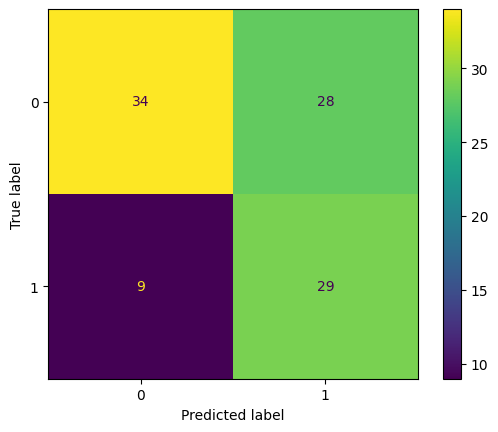

In [8]:
custom_threshold = 0.3 # You can change this value

# Get predicted probabilities for the test set
# model.predict_proba() returns probabilities for class 0 and class 1
p_pred = model.predict_proba(X_test)[:, 1] # We want probability predictions for P(Y=1)

y_pred_new = (p_pred > custom_threshold).astype(int)

# plot the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_new = confusion_matrix(y_test, y_pred_new)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_new,
                              display_labels = model.classes_)
disp.plot()

In [9]:
# compute the accuracy etrics

TN, FP, FN, TP = cm_new.ravel()

# Calculate True Positive Rate (TPR) / Recall
tpr = TP / (TP + FN)

# Calculate False Positive Rate (FPR)
fpr = FP / (FP + TN)

print(f'True Positive Rate (TPR): {tpr:.4f}')
print(f'False Positive Rate (FPR): {fpr:.4f}')

True Positive Rate (TPR): 0.7632
False Positive Rate (FPR): 0.4516


The ROC curve is created by plotting the true positive rate (TPR) against the false positive rate (FPR) at various thresholds.

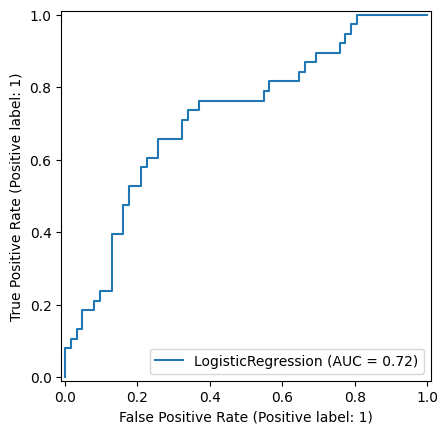

In [10]:
from sklearn.metrics import RocCurveDisplay

# Plot using the fitted estimator
RocCurveDisplay.from_estimator(model, X_test, y_test)

The Area Under the Curve (AUC) measures the entire 2-D area underneath the entire ROC curve. It ranges from 0 to 1, where:
- An AUC of 1 represents a perfect classifier.
- An AUC of 0.5 represents a classifier no better than random guessing.

A higher AUC generally indicates a better performing model.

# **Decision Tree**

We will use the Titanic dataset to train a decision tree.

In [77]:
import pandas as pd

url = 'https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv'
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Let us first handle missing data. `Cabin` has 77% missing data, but "missingness" can be informative. So we will introduce a new binary feature called `HasCabinInfo`.

Missing values in the 'Age' column are imputed with the median, and missing 'Embarked' values are filled with the most frequent value.

In [79]:
# impute missing age
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# impute missing Embarked code
most_frequent_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_frequent_embarked)

# create new feature 'HasCabinInfo'
df['HasCabinInfo'] = df['Cabin'].notna()

print("Missing values handled successfully.")

Missing values handled successfully.


## Engineer New Features

Create new features to enhance the model's predictive power: 'FamilySize' (from 'SibSp' and 'Parch'), 'IsAlone' (from 'FamilySize'), 'logFare' (from 'Fare'), and 'FemaleClass1' (from 'Sex' and 'Pclass')


In [80]:
import numpy as np

# 1. Create 'FamilySize'
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. Create 'IsAlone'
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 3. Apply log transformation to 'Fare' using np.log1p (handles zero values gracefully)
df['logFare'] = np.log1p(df['Fare'])

# 4. Create 'FemaleClass1'
df['FemaleClass1'] = ((df['Sex'] == 'female') & (df['Pclass'] == 1)).astype(int)

print("DataFrame head with new features:")
df.head()

DataFrame head with new features:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabinInfo,FamilySize,IsAlone,logFare,FemaleClass1
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,2,0,2.110213,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,2,0,4.280593,1
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,1,1,2.188856,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,2,0,3.990834,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,1,1,2.202765,0


## Drop Unnecessary Features

Remove original features that are no longer needed after feature engineering or are not suitable for direct use in the model, such as 'Name', 'Ticket', 'Cabin', 'PassengerId', and 'Fare'.


In [81]:
columns_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId', 'Fare']
df.drop(columns=columns_to_drop, inplace=True)

print("DataFrame after dropping unnecessary features:")
df.head()

DataFrame after dropping unnecessary features:


,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,HasCabinInfo,FamilySize,IsAlone,logFare,FemaleClass1
0,0,3,male,22.0,1,0,S,False,2,0,2.110213,0
1,1,1,female,38.0,1,0,C,True,2,0,4.280593,1
2,1,3,female,26.0,0,0,S,False,1,1,2.188856,0
3,1,1,female,35.0,1,0,S,True,2,0,3.990834,1
4,0,3,male,35.0,0,0,S,False,1,1,2.202765,0


## Encode Categorical Features

Encode categorical features ('Sex', 'Embarked', 'Title') using one-hot encoding for use with a Decision Tree classifier.


In [82]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

print("DataFrame after one-hot encoding categorical features:")
df.head()

DataFrame after one-hot encoding categorical features:


,Survived,Pclass,Age,SibSp,Parch,HasCabinInfo,FamilySize,IsAlone,logFare,FemaleClass1,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,False,2,0,2.110213,0,True,False,True
1,1,1,38.0,1,0,True,2,0,4.280593,1,False,False,False
2,1,3,26.0,0,0,False,1,1,2.188856,0,False,False,True
3,1,1,35.0,1,0,True,2,0,3.990834,1,False,False,True
4,0,3,35.0,0,0,False,1,1,2.202765,0,True,False,True


## Split Data into Training and Testing Sets

In [83]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (712, 12)
Shape of X_test: (179, 12)
Shape of y_train: (712,)
Shape of y_test: (179,)


## Train Decision Tree Classifier and Evaluate Performance


In [110]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
# set the hyperparameters
dtc = DecisionTreeClassifier(max_depth = 5,
                             min_samples_split = 2,
                             min_samples_leaf = 2)

# Train the model on the training data
dtc.fit(X_train, y_train)

print("Training decision tree successful.")


Training decision tree successful.


Accuracy: 0.7430


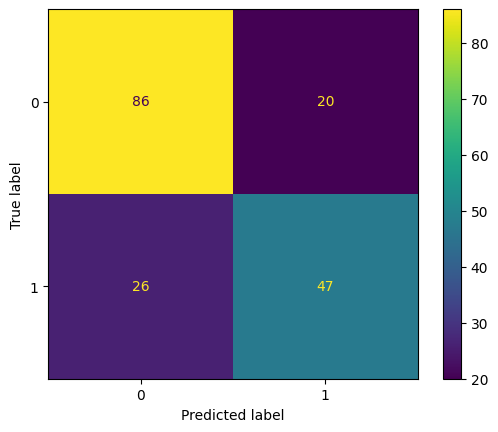

In [111]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate and visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtc.classes_)
disp.plot()

In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

TN, FP, FN, TP = cm.ravel()

# Calculate True Positive Rate (TPR) / Recall
tpr = TP / (TP + FN)

# Calculate False Positive Rate (FPR)
fpr = FP / (FP + TN)

print(f'True Positive Rate (TPR): {tpr:.4f}')
print(f'False Positive Rate (FPR): {fpr:.4f}')

# Calculate other accuracy metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

True Positive Rate (TPR): 0.6438
False Positive Rate (FPR): 0.1887
Accuracy: 0.7430
Precision: 0.7015
Recall: 0.6438
F1-Score: 0.6714


## Visualize the Decision Tree

Visualize the trained `DecisionTreeClassifier` to understand its decision-making process. This can be done using `plot_tree` from `sklearn.tree`.

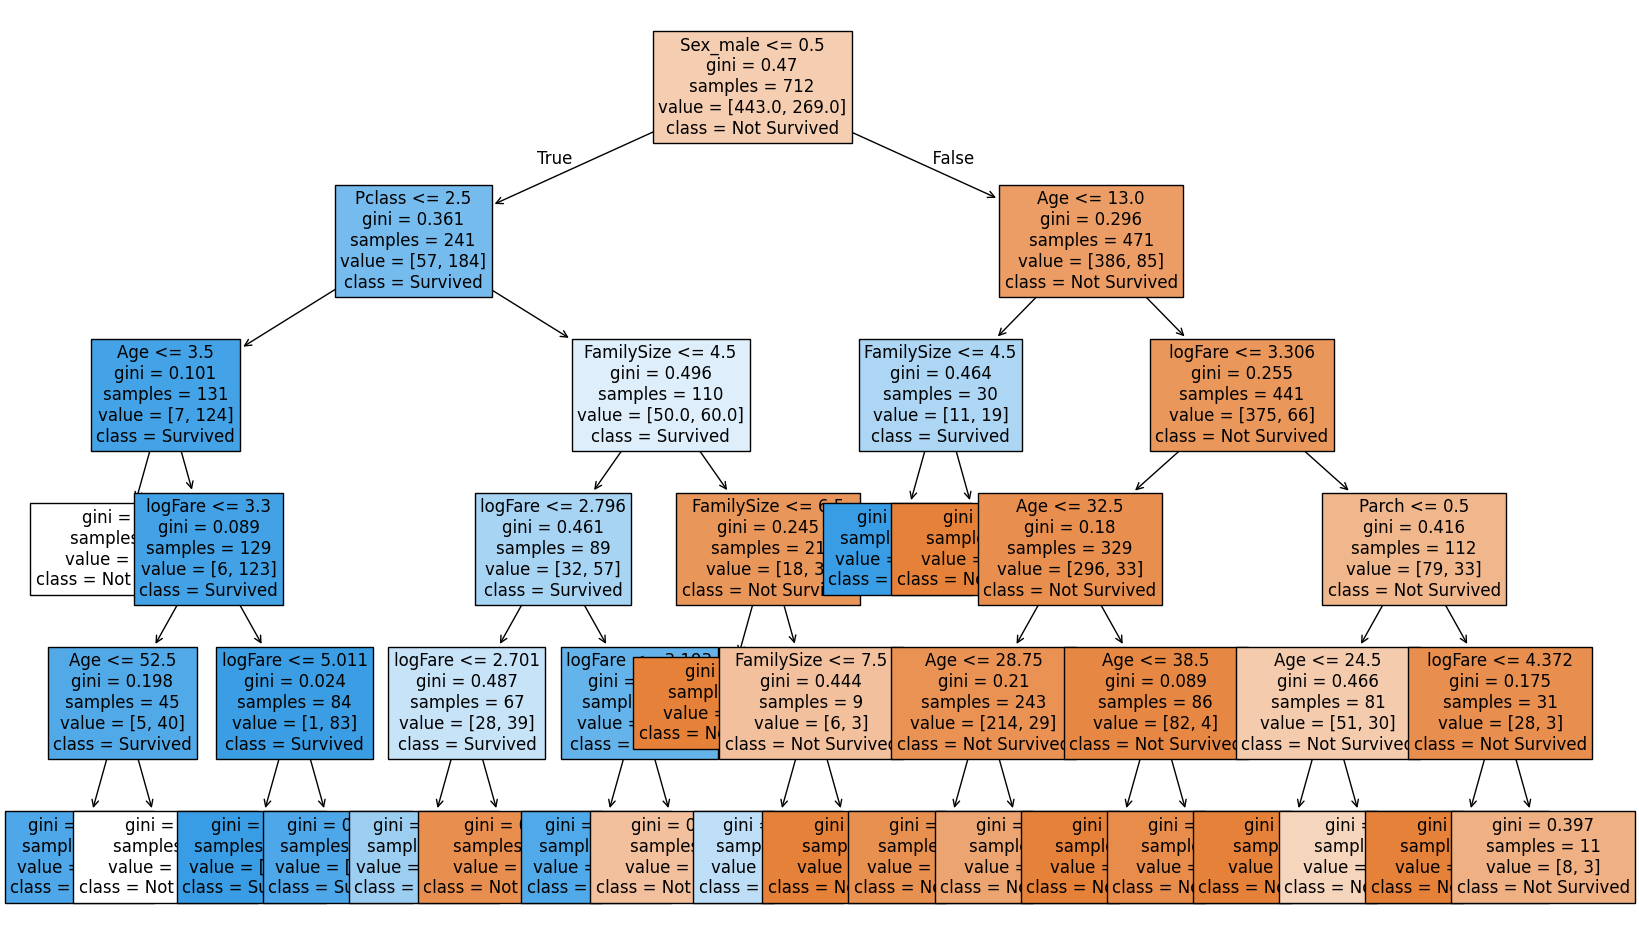

In [113]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,12))  # set plot size (denoted in inches)
plot_tree(dtc, feature_names=X.columns.tolist(),
          class_names=['Not Survived', 'Survived'],
          filled=True, fontsize=12)
plt.show()

## Feature Importance Plot

<Axes: xlabel='importance', ylabel='feature'>

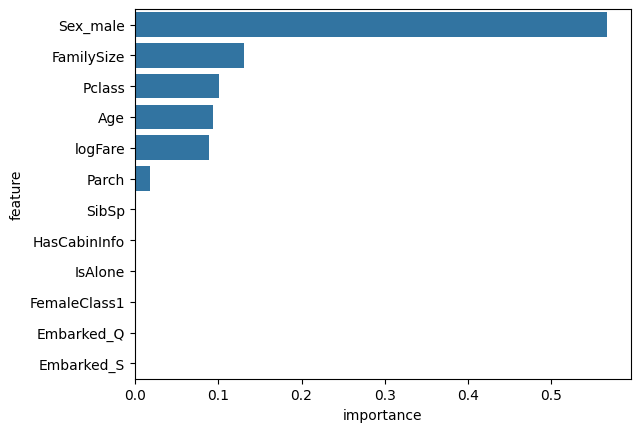

In [114]:
import pandas as pd
import seaborn as sns

# extract the importance of features
importances = dtc.feature_importances_
feature_names = X.columns

# define a dataframe for easy plotting
feature_importance_df = pd.DataFrame({'feature': feature_names,
                                      'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# generate the feature importance plot
sns.barplot(y='feature', x='importance', data=feature_importance_df)